In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [3]:
# read in model data for each station
station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]

data_lo = {}
data_ssc = {}

for station in station_names:
    filename_lo = f"{station}_2014.01.01_2014.12.31.nc"
    filename_ssc = f"{station}_2014.01.01_2014.12.31_ssc.nc"
    filepath_lo = "../stations/" + filename_lo
    filepath_ssc = "../stations/" + filename_ssc

    data_lo[station] = xr.open_dataset(filepath_lo)
    data_ssc[station] = xr.open_dataset(filepath_ssc)

In [13]:
station = "SAR003"

print(data_lo[station].data_vars)

Data variables:
    Cs_r           (s_rho) float64 240B ...
    LdetritusC     (ocean_time, s_rho) float32 44kB ...
    LdetritusN     (ocean_time, s_rho) float32 44kB ...
    NH4            (ocean_time, s_rho) float32 44kB ...
    NO3            (ocean_time, s_rho) float32 44kB ...
    SdetritusC     (ocean_time, s_rho) float32 44kB ...
    SdetritusN     (ocean_time, s_rho) float32 44kB ...
    TIC            (ocean_time, s_rho) float32 44kB ...
    Uwind          (ocean_time) float32 1kB ...
    Vwind          (ocean_time) float32 1kB ...
    alkalinity     (ocean_time, s_rho) float32 44kB ...
    h              float64 8B 121.6
    hc             float64 8B ...
    oxygen         (ocean_time, s_rho) float32 44kB ...
    phytoplankton  (ocean_time, s_rho) float32 44kB ...
    salt           (ocean_time, s_rho) float32 44kB ...
    shflux         (ocean_time) float32 1kB ...
    temp           (ocean_time, s_rho) float32 44kB ...
    u              (ocean_time, s_rho) float32 44kB ..

In [12]:
for station in station_names:
    ds = data_lo[station]

    max_depth = ds["z_rho"].min().item()   # deepest rho level (m)
    h = ds["h"].item()                     # bathymetry (m)

    print(f"{station:6s}: deepest z_rho = {max_depth:7.2f} m, bathymetry = {h:7.2f} m")

SAR003: deepest z_rho = -118.90 m, bathymetry =  121.58 m
PSS019: deepest z_rho =  -60.88 m, bathymetry =   62.23 m
SKG003: deepest z_rho =  -11.53 m, bathymetry =   11.76 m
HCB004: deepest z_rho =  -30.89 m, bathymetry =   31.55 m
HCB003: deepest z_rho =  -95.71 m, bathymetry =   97.85 m
ADM003: deepest z_rho = -203.12 m, bathymetry =  207.72 m
CMB003: deepest z_rho = -131.46 m, bathymetry =  134.42 m
GOR001: deepest z_rho = -163.00 m, bathymetry =  166.68 m
CSE001: deepest z_rho =  -46.35 m, bathymetry =   47.36 m
EAP001: deepest z_rho = -198.89 m, bathymetry =  203.39 m
SIN001: deepest z_rho =  -12.31 m, bathymetry =   12.56 m
PSB003: deepest z_rho =  -67.06 m, bathymetry =   68.55 m


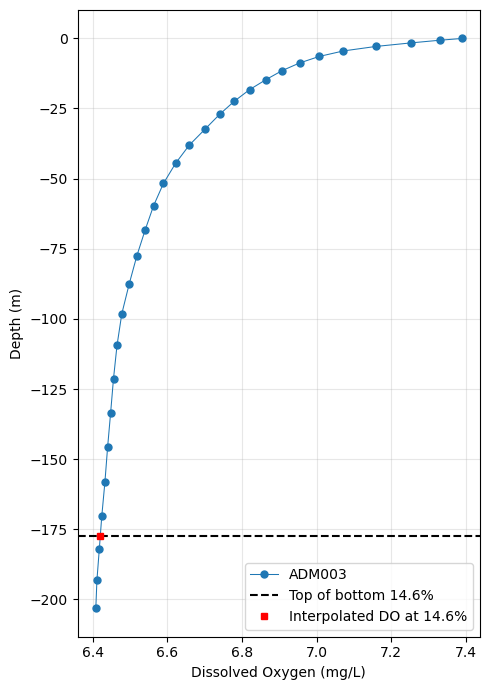

In [32]:
#station = "SKG003"
station = "ADM003"

plt.figure(figsize=(5, 7))

ds = data_lo[station]

# First time step
do = ds["oxygen"].isel(ocean_time=0) * 0.032  # µmol/L -> mg/L
z = ds["z_rho"].isel(ocean_time=0)

# Plot rho points
plt.plot(do, z, '-o', lw=0.75, markersize=5, label=station)

# Bottom 14.6% of the water column
h = ds["h"].item()
z_146 = -0.854 * h

plt.axhline(
    z_146,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="Top of bottom 14.6%"
)

# Sort by depth for interpolation
idx = np.argsort(z)
z_sorted = z[idx]
do_sorted = do[idx]

# Interpolate DO at z_146
do_146 = np.interp(z_146, z_sorted, do_sorted)

plt.plot(do_146, z_146, "s", markersize=5, color="red", label="Interpolated DO at 14.6%")

plt.xlabel("Dissolved Oxygen (mg/L)")
plt.ylabel("Depth (m)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# thickness of each cell